<a href="https://colab.research.google.com/github/LIBY70/Data-Analysis/blob/main/ida_week14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab14: 로지스틱 회귀 & SVM

본 실습 자료는 『배워서 바로 써먹는 데이터 분석 with 파이썬』 (설진욱, 생능북스) 및
『파이썬을 활용한 빅데이터 분석개론』 (안기수, 생능출판사)의 내용을 참고하여 제작되었습니다.

## 0. 라이브러리 불러오기

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer, load_iris, make_circles
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_curve, auc, roc_auc_score
)

### 한글 폰트 설정

In [2]:
!apt-get install -y fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (30.4 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [3]:
import platform

if platform.system() == 'Darwin':
    mpl.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    mpl.rc('font', family='Malgun Gothic')
else:
    import matplotlib.font_manager as fm
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
    mpl.rc('font', family='NanumGothic')

mpl.rc('axes', unicode_minus=False)
print('폰트 설정 완료:', mpl.rcParams['font.family'])

폰트 설정 완료: ['NanumGothic']


---
## PART 1. 로지스틱 회귀 기초

**분류 문제**란 출력이 연속값이 아닌 **클래스(범주)**인 예측 문제다.  
선형 회귀를 분류에 그대로 쓰면 세 가지 문제가 생긴다.

| 문제 | 설명 |
|---|---|
| **범위 초과** | 예측값이 0 미만 또는 1 초과 → 확률 해석 불가 |
| **경계 왜곡** | 이상치 하나가 결정 경계 전체를 이동시킴 |
| **순서 가정** | 3-클래스(고양이=1, 개=2, 새=3)에 순서 의미 부여 |

**해결책**: 출력을 **확률 (0 ≤ p ≤ 1)** 로 변환하는 **Sigmoid 함수** 사용

### 1-1. 선형 회귀 vs 로지스틱 회귀 — 분류 문제에서의 차이

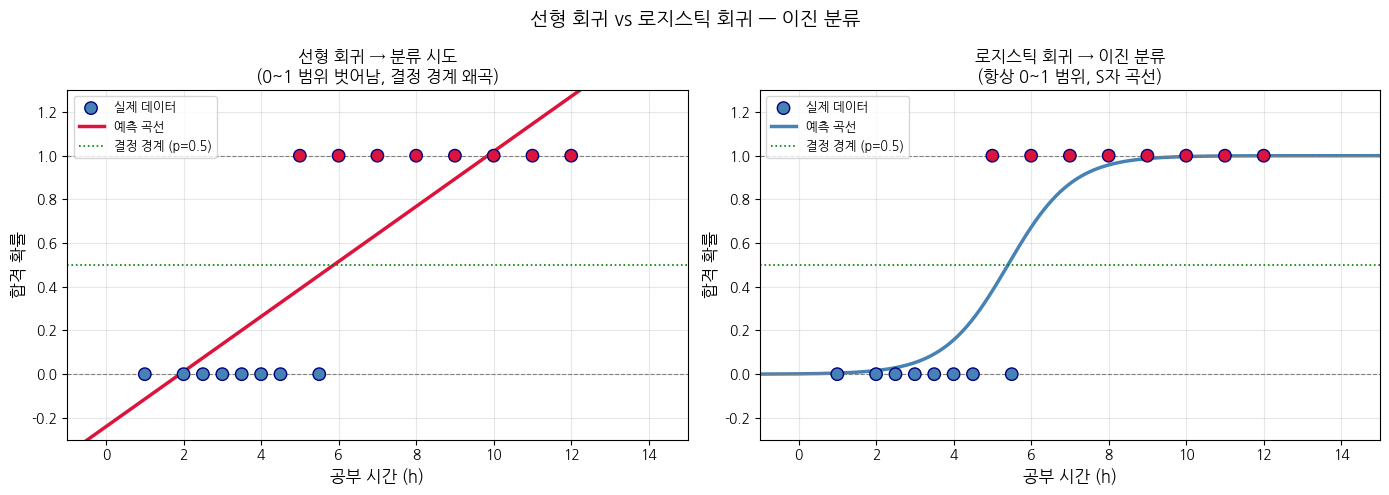

선형 회귀: 예측값이 0 미만·1 초과 가능 → 확률 해석 불가
로지스틱 회귀: Sigmoid로 변환 → 항상 0~1 사이 → 확률로 해석 가능


In [4]:
np.random.seed(42)

# 이진 분류용 단순 데이터 (공부시간 → 합격/불합격)
x_study = np.array([1, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 6,
                    7, 8, 9, 10, 11, 12])
y_pass   = np.array([0, 0,   0, 0,   0, 0,   0, 1,   0, 1,
                     1, 1,  1,  1,   1,  1])

# 선형 회귀 피팅
from sklearn.linear_model import LinearRegression
lr_line = LinearRegression()
lr_line.fit(x_study.reshape(-1, 1), y_pass)
x_plot  = np.linspace(-1, 15, 300)
y_lr    = lr_line.predict(x_plot.reshape(-1, 1))

# 로지스틱 회귀 피팅
from sklearn.linear_model import LogisticRegression
logit = LogisticRegression()
logit.fit(x_study.reshape(-1, 1), y_pass)
y_logit = logit.predict_proba(x_plot.reshape(-1, 1))[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (y_pred, title, color) in zip(axes, [
    (y_lr,    '선형 회귀 → 분류 시도\n(0~1 범위 벗어남, 결정 경계 왜곡)', 'crimson'),
    (y_logit, '로지스틱 회귀 → 이진 분류\n(항상 0~1 범위, S자 곡선)', 'steelblue'),
]):
    ax.scatter(x_study, y_pass, zorder=5, s=80,
               c=['crimson' if v else 'steelblue' for v in y_pass],
               edgecolors='navy', label='실제 데이터')
    ax.plot(x_plot, y_pred, color=color, linewidth=2.5, label='예측 곡선')
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.axhline(1, color='gray', linewidth=0.8, linestyle='--')
    ax.axhline(0.5, color='green', linewidth=1.2, linestyle=':', label='결정 경계 (p=0.5)')
    ax.set_xlabel('공부 시간 (h)', fontsize=12)
    ax.set_ylabel('합격 확률', fontsize=12)
    ax.set_title(title, fontsize=12)
    ax.set_ylim(-0.3, 1.3)
    ax.set_xlim(-1, 15)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('선형 회귀 vs 로지스틱 회귀 — 이진 분류', fontsize=14)
plt.tight_layout()
plt.show()

print("선형 회귀: 예측값이 0 미만·1 초과 가능 → 확률 해석 불가")
print("로지스틱 회귀: Sigmoid로 변환 → 항상 0~1 사이 → 확률로 해석 가능")

### 1-2. Sigmoid 함수

임의의 실수 입력을 $(0, 1)$ 범위의 **확률**로 변환하는 함수

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

- $z \to +\infty$ : $\sigma(z) \to 1$
- $z \to -\infty$ : $\sigma(z) \to 0$
- $z = 0$ : $\sigma(0) = 0.5$ → **결정 경계**
- $z = \mathbf{w}^T\mathbf{x} + b$ (선형 결합)

로지스틱 회귀 예측: $\hat{P}(y=1|\mathbf{x}) = \sigma(\mathbf{w}^T\mathbf{x} + b)$

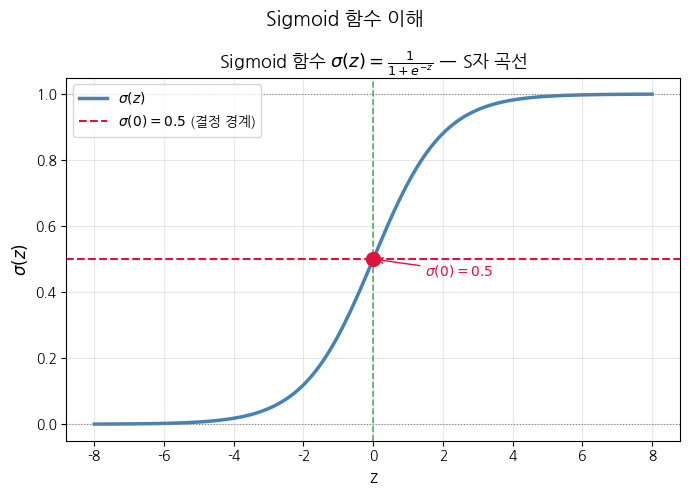

Sigmoid 핵심: 어떤 실수 z도 (0, 1) 사이로 압축 → 확률로 해석 가능
z=0이 결정 경계: z>0 → P>0.5 → 클래스 1 예측


In [5]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-8, 8, 300)
sig = sigmoid(z)

fig, ax = plt.subplots(1, 1, figsize=(7, 5))

# Sigmoid 곡선
ax.plot(z, sig, color='steelblue', linewidth=2.5, label=r'$\sigma(z)$')
ax.axhline(0.5, color='crimson',    linewidth=1.5, linestyle='--', label=r'$\sigma(0) = 0.5$ (결정 경계)')
ax.axhline(0,   color='gray',       linewidth=0.8, linestyle=':')
ax.axhline(1,   color='gray',       linewidth=0.8, linestyle=':')
ax.axvline(0,   color='forestgreen', linewidth=1.2, linestyle='--', alpha=0.7)
ax.scatter([0], [0.5], color='crimson', s=100, zorder=5)
ax.annotate(r'$\sigma(0)=0.5$', xy=(0, 0.5), xytext=(1.5, 0.45), fontsize=10,
            arrowprops=dict(arrowstyle='->', color='crimson'), color='crimson')
ax.set_xlabel('z', fontsize=12)
ax.set_ylabel(r'$\sigma(z)$', fontsize=12)
ax.set_title("Sigmoid 함수 " + r"$\sigma(z) = \frac{1}{1+e^{-z}}$" + " — S자 곡선", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)

plt.suptitle('Sigmoid 함수 이해', fontsize=14)
plt.tight_layout()
plt.show()

print("Sigmoid 핵심: 어떤 실수 z도 (0, 1) 사이로 압축 → 확률로 해석 가능")
print("z=0이 결정 경계: z>0 → P>0.5 → 클래스 1 예측")

### 1-3. Odds와 Log-Odds (Logit)

로지스틱 회귀는 **확률의 변환**을 통해 선형 모델과 연결된다.

- 확률:  $p \in [0, 1]$
- Odds: $\frac{p}{1-p} \in [0, +\infty)$
- Log-Odds (Logit): $\ln\frac{p}{1-p} \in (-\infty, +\infty)$

선형 모델과 연결:
$$\ln\frac{p}{1-p} = \mathbf{w}^T\mathbf{x} + b$$

Logit을 역변환하면 Sigmoid:
$$p = \frac{1}{1 + e^{-(\mathbf{w}^T\mathbf{x}+b)}} = \sigma(\mathbf{w}^T\mathbf{x}+b)$$

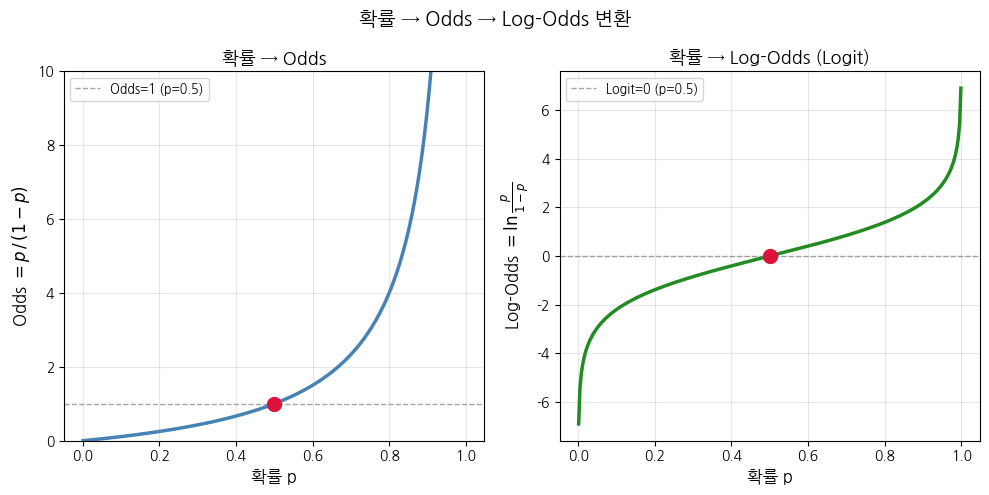

Logit(Log-Odds)은 확률을 (-∞, +∞)로 펼쳐줌 → 선형 모델과 연결 가능
핵심: 로지스틱 회귀는 Log-Odds를 선형으로 모델링 → Sigmoid로 역변환하여 확률 출력


In [6]:
p = np.linspace(0.001, 0.999, 300)
odds    = p / (1 - p)
logodds = np.log(odds)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# 확률 → Odds
ax = axes[0]
ax.plot(p, odds, color='steelblue', linewidth=2.5)
ax.axhline(1, color='gray', linewidth=1, linestyle='--', alpha=0.7, label='Odds=1 (p=0.5)')
ax.scatter([0.5], [1], color='crimson', s=100, zorder=5)
ax.set_xlabel('확률 p', fontsize=12)
ax.set_ylabel(r'Odds $= p\,/\,(1-p)$', fontsize=12)
ax.set_title('확률 → Odds', fontsize=13)
ax.legend(fontsize=9)
ax.set_ylim(0, 10)
ax.grid(True, alpha=0.3)

# 확률 → Log-Odds
ax = axes[1]
ax.plot(p, logodds, color='forestgreen', linewidth=2.5)
ax.axhline(0, color='gray', linewidth=1, linestyle='--', alpha=0.7, label='Logit=0 (p=0.5)')
ax.scatter([0.5], [0], color='crimson', s=100, zorder=5)
ax.set_xlabel('확률 p', fontsize=12)
ax.set_ylabel(r'Log-Odds $= \ln\frac{p}{1-p}$', fontsize=12)
ax.set_title('확률 → Log-Odds (Logit)', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('확률 → Odds → Log-Odds 변환', fontsize=14)
plt.tight_layout()
plt.show()

print("Logit(Log-Odds)은 확률을 (-∞, +∞)로 펼쳐줌 → 선형 모델과 연결 가능")
print("핵심: 로지스틱 회귀는 Log-Odds를 선형으로 모델링 → Sigmoid로 역변환하여 확률 출력")

---
## PART 2. 로지스틱 회귀 실전 — 유방암 진단

**데이터셋**: `sklearn.datasets.load_breast_cancer()`
- 표본: **569개** (악성 212개 / 정상 357개)
- 변수: **30개** 수치형 특성 (세포핵 반지름, 텍스처, 둘레, 면적 등)
- 목표: 악성(malignant) / 정상(benign) **이진 분류**

**레이블 관례** (이전 Lab12와 동일)

| 레이블 | 의미 | 분류 역할 |
|---|---|---|
| **1** | 악성 (malignant, 암) | **Positive** |
| **0** | 정상 (benign) | Negative |

- FN(암 환자를 정상으로 진단)이 FP보다 훨씬 위험 → **Recall** 우선

### 2-1. 데이터 준비

In [7]:
cancer = load_breast_cancer()

df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['진단'] = 1 - cancer.target   # 반전: 1=악성(Positive), 0=정상(Negative)
df['진단명'] = df['진단'].map({0: '정상', 1: '악성'})

print(f"데이터 크기: {df.shape}")
print(f"클래스 분포:\n{df['진단명'].value_counts()}")
print()
df.head()

데이터 크기: (569, 32)
클래스 분포:
진단명
정상    357
악성    212
Name: count, dtype: int64



,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,진단,진단명
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1,악성
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1,악성
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1,악성
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1,악성
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1,악성


In [8]:
X = cancer.data
y = 1 - cancer.target   # 악성=1, 정상=0
class_names_kr = ['정상(benign)', '악성(malignant)']

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 로지스틱 회귀는 거리 기반은 아니지만 표준화하면 계수 해석이 용이
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc  = scaler.transform(X_te)

print(f"훈련셋: {X_tr.shape[0]}개  (악성 {(y_tr==1).sum()} / 정상 {(y_tr==0).sum()})")
print(f"테스트셋: {X_te.shape[0]}개  (악성 {(y_te==1).sum()} / 정상 {(y_te==0).sum()})")

훈련셋: 455개  (악성 170 / 정상 285)
테스트셋: 114개  (악성 42 / 정상 72)


### 2-2. 모델 학습 및 계수 해석 — Odds Ratio

로지스틱 회귀 계수 $w_j$는 **다른 변수 고정 시 $x_j$가 1 증가할 때의 log-odds 변화량**

$$\text{Odds Ratio} = e^{w_j}$$

- $e^{w_j} > 1$: $x_j$ 증가 시 양성(악성) 확률 **증가**
- $e^{w_j} < 1$: $x_j$ 증가 시 양성(악성) 확률 **감소**
- $e^{w_j} = 1$: $x_j$가 확률에 영향 없음

In [9]:
logit_cancer = LogisticRegression(max_iter=1000, random_state=42)
logit_cancer.fit(X_tr_sc, y_tr)

y_pred_logit = logit_cancer.predict(X_te_sc)
y_prob_logit = logit_cancer.predict_proba(X_te_sc)[:, 1]

print("로지스틱 회귀 — 유방암 진단")
print(f"훈련 정확도: {logit_cancer.score(X_tr_sc, y_tr):.4f}")
print(f"테스트 정확도: {logit_cancer.score(X_te_sc, y_te):.4f}")
print()
print(classification_report(y_te, y_pred_logit, target_names=class_names_kr))

로지스틱 회귀 — 유방암 진단
훈련 정확도: 0.9868
테스트 정확도: 0.9649

               precision    recall  f1-score   support

   정상(benign)       0.96      0.99      0.97        72
악성(malignant)       0.97      0.93      0.95        42

     accuracy                           0.96       114
    macro avg       0.97      0.96      0.96       114
 weighted avg       0.97      0.96      0.96       114



### 2-3. 예측 확률 분포 시각화

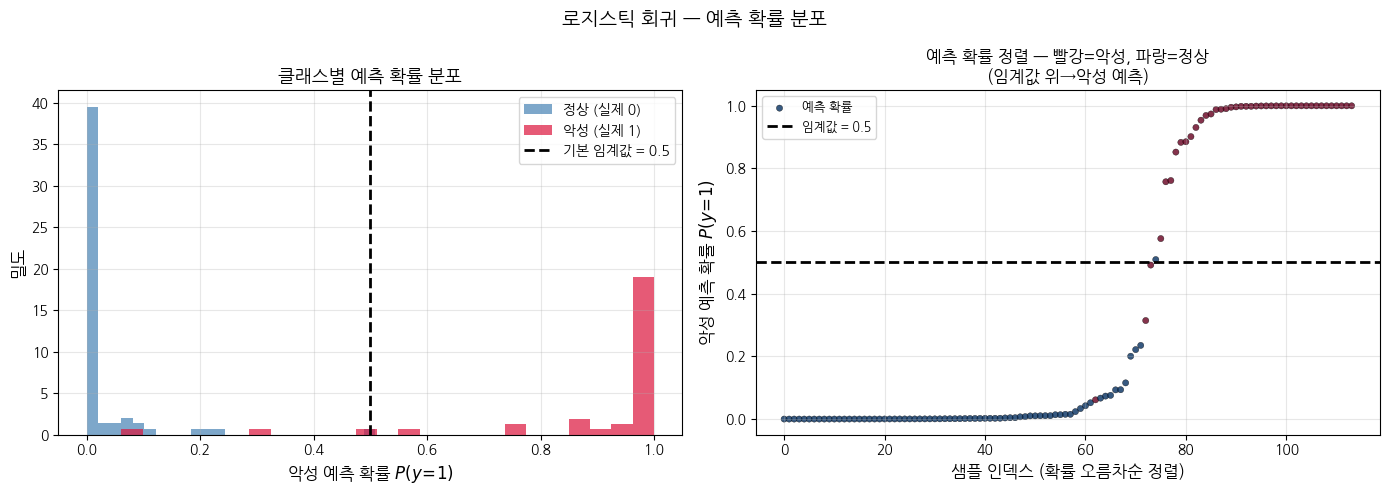

두 클래스가 잘 분리됨: 정상 샘플은 낮은 확률, 악성 샘플은 높은 확률에 집중


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 클래스별 예측 확률 분포
ax = axes[0]
prob_malignant = y_prob_logit[y_te == 1]
prob_benign    = y_prob_logit[y_te == 0]

ax.hist(prob_benign,    bins=25, alpha=0.7, color='steelblue', label='정상 (실제 0)', density=True)
ax.hist(prob_malignant, bins=25, alpha=0.7, color='crimson',   label='악성 (실제 1)', density=True)
ax.axvline(0.5, color='black', linewidth=2, linestyle='--', label='기본 임계값 = 0.5')
ax.set_xlabel(r'악성 예측 확률 $P(y\!=\!1)$', fontsize=12)
ax.set_ylabel('밀도', fontsize=12)
ax.set_title('클래스별 예측 확률 분포', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# 정렬된 확률값과 실제 레이블
ax = axes[1]
sort_idx = np.argsort(y_prob_logit)
x_idx    = np.arange(len(sort_idx))
ax.scatter(x_idx, y_prob_logit[sort_idx],
           c=y_te[sort_idx], cmap='RdBu_r',
           edgecolors='k', s=20, linewidths=0.3, alpha=0.8, label='예측 확률')
ax.axhline(0.5, color='black', linewidth=2, linestyle='--', label='임계값 = 0.5')
ax.set_xlabel('샘플 인덱스 (확률 오름차순 정렬)', fontsize=12)
ax.set_ylabel(r'악성 예측 확률 $P(y\!=\!1)$', fontsize=12)
ax.set_title('예측 확률 정렬 — 빨강=악성, 파랑=정상\n(임계값 위→악성 예측)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('로지스틱 회귀 — 예측 확률 분포', fontsize=14)
plt.tight_layout()
plt.show()

print(f"두 클래스가 잘 분리됨: 정상 샘플은 낮은 확률, 악성 샘플은 높은 확률에 집중")

### 2-4. 모델 평가 — 혼동 행렬 & ROC/AUC

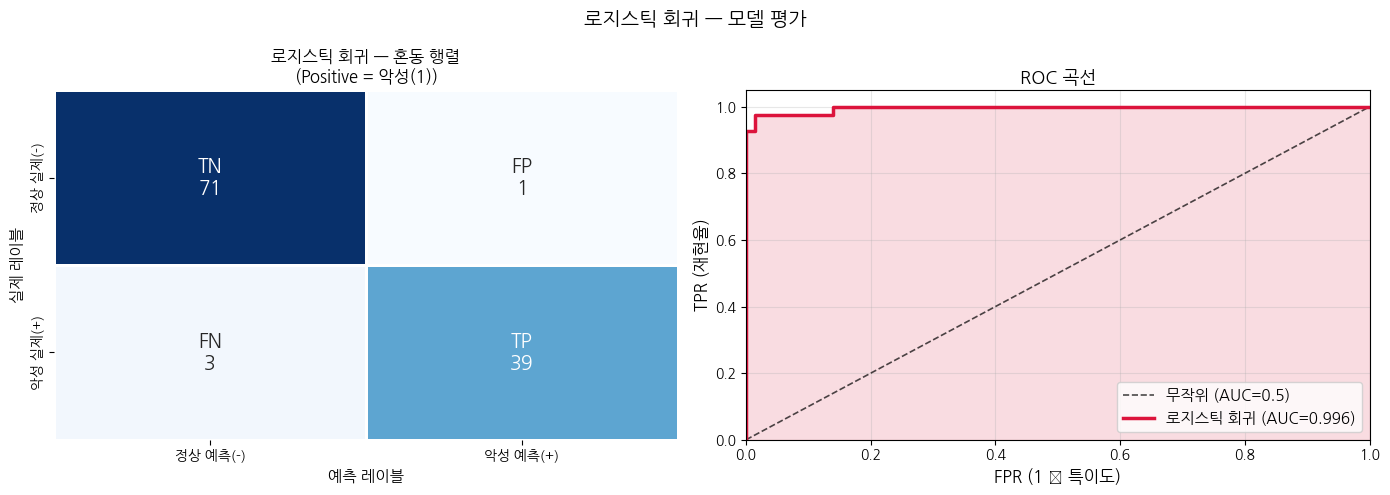

정확도:  0.9649
Recall:  0.9286  ← 암 진단에서 핵심 지표
Precision: 0.9750
F1-Score: 0.9512
AUC:     0.9960
FN (암 환자 → 정상 진단): 3명  ← 최소화가 목표


In [11]:
cm = confusion_matrix(y_te, y_pred_logit)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 혼동 행렬
ax = axes[0]
labels = np.array([
    [f'TN\n{tn}', f'FP\n{fp}'],
    [f'FN\n{fn}', f'TP\n{tp}']
])
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues',
            xticklabels=['정상 예측(-)', '악성 예측(+)'],
            yticklabels=['정상 실제(-)', '악성 실제(+)'],
            ax=ax, cbar=False, linewidths=1,
            annot_kws={'size': 14})
ax.set_title('로지스틱 회귀 — 혼동 행렬\n(Positive = 악성(1))', fontsize=12)
ax.set_xlabel('예측 레이블', fontsize=11)
ax.set_ylabel('실제 레이블', fontsize=11)

# ROC 곡선
ax = axes[1]
fpr_arr, tpr_arr, _ = roc_curve(y_te, y_prob_logit)
roc_auc_val = auc(fpr_arr, tpr_arr)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='무작위 (AUC=0.5)', alpha=0.7)
ax.plot(fpr_arr, tpr_arr, color='crimson', linewidth=2.5,
        label=f'로지스틱 회귀 (AUC={roc_auc_val:.3f})')
ax.fill_between(fpr_arr, tpr_arr, alpha=0.15, color='crimson')
ax.set_xlabel('FPR (1 − 특이도)', fontsize=12)
ax.set_ylabel('TPR (재현율)', fontsize=12)
ax.set_title('ROC 곡선', fontsize=13)
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

plt.suptitle('로지스틱 회귀 — 모델 평가', fontsize=14)
plt.tight_layout()
plt.show()

print(f"정확도:  {accuracy_score(y_te, y_pred_logit):.4f}")
print(f"Recall:  {recall_score(y_te, y_pred_logit):.4f}  ← 암 진단에서 핵심 지표")
print(f"Precision: {precision_score(y_te, y_pred_logit):.4f}")
print(f"F1-Score: {f1_score(y_te, y_pred_logit):.4f}")
print(f"AUC:     {roc_auc_val:.4f}")
print(f"FN (암 환자 → 정상 진단): {fn}명  ← 최소화가 목표")

---
## PART 3. 다중 클래스 로지스틱 회귀

클래스가 3개 이상일 때의 확장 방식 — **OvR** 또는 **Softmax**

| 방식 | 설명 | 특징 |
|---|---|---|
| **OvR (One-vs-Rest)** | 클래스 수만큼 이진 분류기 학습 | K개 모델 독립 학습, 확률 합 ≠ 1 |
| **Softmax (Multinomial)** | 모든 클래스를 동시에 학습 | 확률 합 = 1, 클래스 간 관계 고려 |

### 3-1. 붓꽃 데이터 — 3-클래스 분류

데이터 크기: (150, 6)
클래스: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
클래스별 샘플 수:
품종명
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64



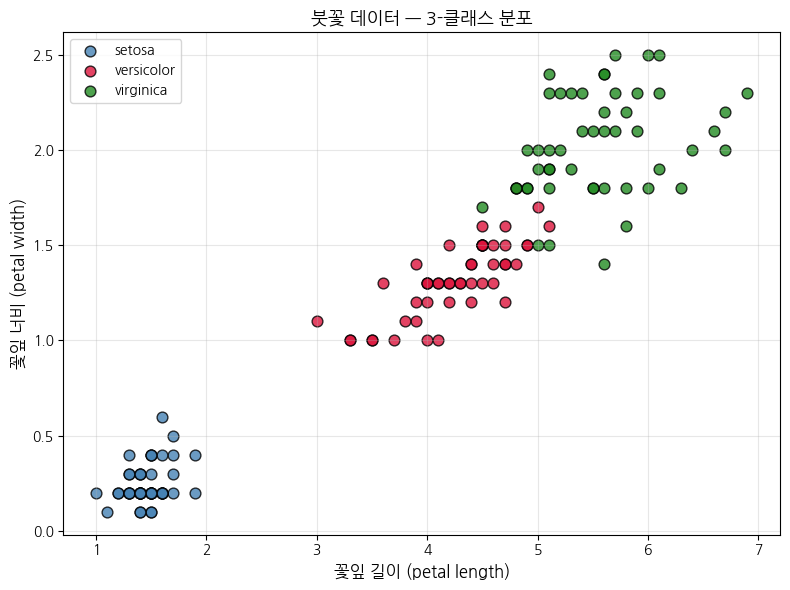

In [12]:
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['품종'] = iris.target
df_iris['품종명'] = [iris.target_names[t] for t in iris.target]

print(f"데이터 크기: {df_iris.shape}")
print(f"클래스: {list(iris.target_names)}")
print(f"클래스별 샘플 수:\n{df_iris['품종명'].value_counts()}")
print()

# 시각화: 꽃잎 길이 vs 꽃잎 너비
fig, ax = plt.subplots(figsize=(8, 6))
colors_iris = ['steelblue', 'crimson', 'forestgreen']
for i, (species, color) in enumerate(zip(iris.target_names, colors_iris)):
    mask = iris.target == i
    ax.scatter(iris.data[mask, 2], iris.data[mask, 3],
               c=color, edgecolors='k', s=60, alpha=0.8, label=species)
ax.set_xlabel('꽃잎 길이 (petal length)', fontsize=12)
ax.set_ylabel('꽃잎 너비 (petal width)', fontsize=12)
ax.set_title('붓꽃 데이터 — 3-클래스 분포', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3-2. Softmax (Multinomial) 분류

Softmax 정확도: 0.9667



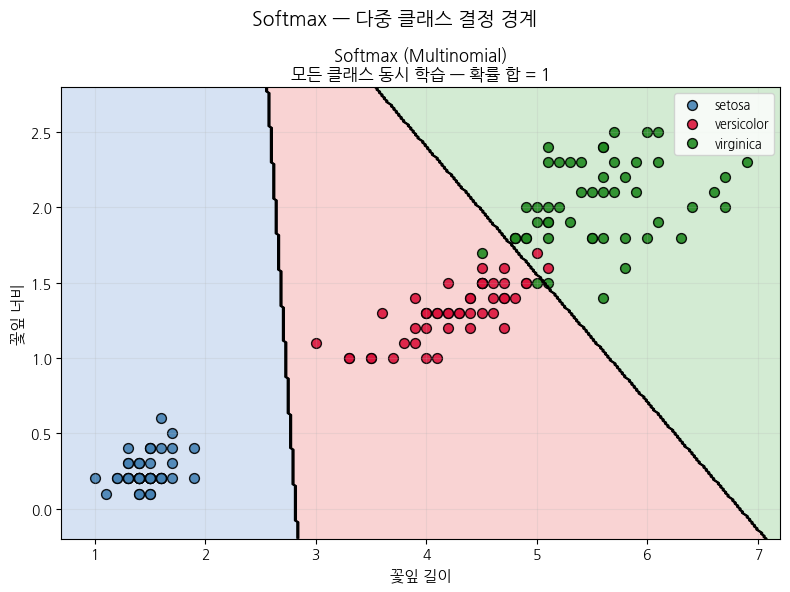

샘플별 예측 확률 (클래스: setosa / versicolor / virginica)
          샘플      setosa    versicolor    virginica        합계
(3.0, 1.0):  0.3266  0.6721  0.0013  1.0000
(4.5, 1.5):  0.0060  0.7875  0.2065  1.0000
(5.5, 2.0):  0.0000  0.0832  0.9168  1.0000


In [13]:
X_iris = iris.data[:, 2:4]   # 꽃잎 길이, 너비 (시각화용 2D)
y_iris = iris.target

X_ir_tr, X_ir_te, y_ir_tr, y_ir_te = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

# Softmax (Multinomial) 로지스틱 회귀
logit_smx = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
logit_smx.fit(X_ir_tr, y_ir_tr)

print(f"Softmax 정확도: {logit_smx.score(X_ir_te, y_ir_te):.4f}")
print()

# 결정 경계 시각화
x_min, x_max = X_iris[:, 0].min() - 0.3, X_iris[:, 0].max() + 0.3
y_min, y_max = X_iris[:, 1].min() - 0.3, X_iris[:, 1].max() + 0.3
xx_ir, yy_ir = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)
grid = np.c_[xx_ir.ravel(), yy_ir.ravel()]

fig, ax = plt.subplots(figsize=(8, 6))
cmap_iris = mpl.colors.ListedColormap(['#aec6e8', '#f4a8a8', '#a8d8a8'])
colors_iris = ['steelblue', 'crimson', 'forestgreen']

Z_ir = logit_smx.predict(grid).reshape(xx_ir.shape)
ax.contourf(xx_ir, yy_ir, Z_ir, alpha=0.5, cmap=cmap_iris)
ax.contour(xx_ir, yy_ir, Z_ir, colors='black', linewidths=1.0)
for i, (species, color) in enumerate(zip(iris.target_names, colors_iris)):
    mask = y_iris == i
    ax.scatter(X_iris[mask, 0], X_iris[mask, 1],
               c=color, edgecolors='k', s=50, alpha=0.9, label=species)
ax.set_xlabel('꽃잎 길이', fontsize=11)
ax.set_ylabel('꽃잎 너비', fontsize=11)
ax.set_title('Softmax (Multinomial)\n모든 클래스 동시 학습 — 확률 합 = 1', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

plt.suptitle('Softmax — 다중 클래스 결정 경계', fontsize=14)
plt.tight_layout()
plt.show()

# 예측 확률 (샘플 3개)
sample_x = np.array([[3.0, 1.0], [4.5, 1.5], [5.5, 2.0]])
print("샘플별 예측 확률 (클래스: setosa / versicolor / virginica)")
print(f"{'샘플':>12}  {'setosa':>10}  {'versicolor':>12}  {'virginica':>11}  {'합계':>8}")
for xi in sample_x:
    prob = logit_smx.predict_proba([xi])[0]
    print(f"({xi[0]:.1f}, {xi[1]:.1f}):  "
          f"{prob[0]:.4f}  {prob[1]:.4f}  {prob[2]:.4f}  {prob.sum():.4f}")


---
## PART 4. SVM (Support Vector Machine)

**핵심 아이디어**: 두 클래스를 가장 **넓게** 나누는 결정 경계를 찾는 알고리즘

| 개념 | 설명 |
|---|---|
| **결정 초평면** | 두 클래스를 나누는 경계: $\mathbf{w}^T\mathbf{x} + b = 0$ |
| **Support Vectors** | 결정 경계에 **가장 가까운** 데이터 포인트들, 이 점들만이 경계를 결정 |
| **마진(Margin)** | 두 클래스 support vector 간 거리 $= \frac{2}{\|\mathbf{w}\|}$ |

**SVM 목표**: 마진을 최대화 → 일반화 성능(새 데이터 예측력) 향상
$$\max_{\mathbf{w}, b} \frac{2}{\|\mathbf{w}\|} \iff \min_{\mathbf{w}, b} \frac{1}{2}\|\mathbf{w}\|^2$$

### 4-1. 최대 마진 분류기 — 선형 SVM

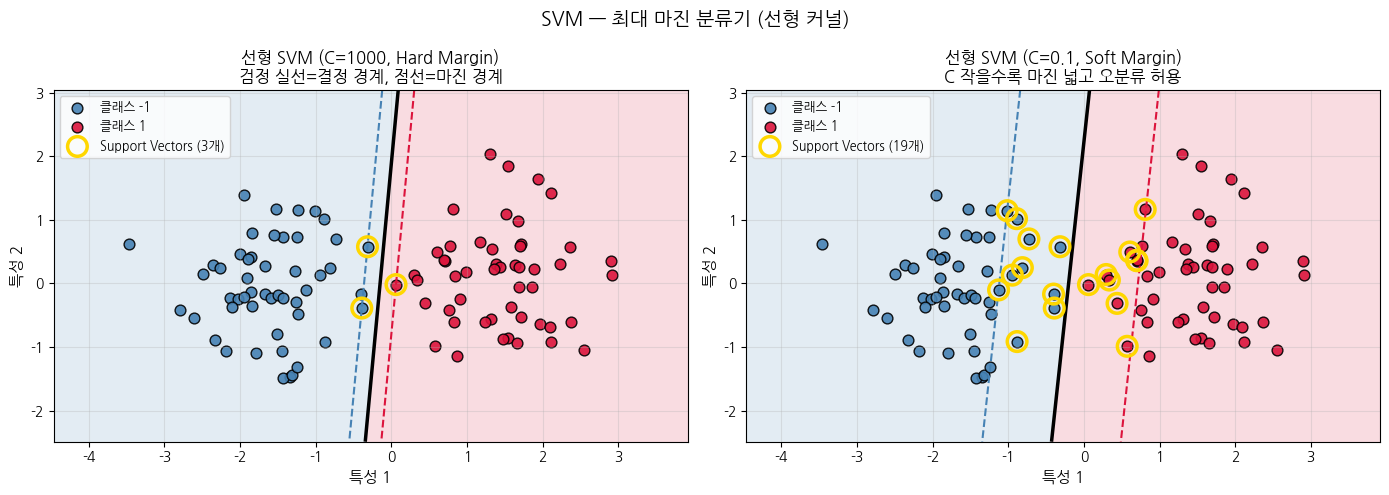

Hard Margin SVM Support Vectors 수: 3개
Soft Margin SVM Support Vectors 수: 19개

C 크면: 마진 좁고 오분류 거의 없음 (하드 마진, 과적합 위험)
C 작으면: 마진 넓고 일부 오분류 허용 (소프트 마진, 일반화 향상)


In [14]:
np.random.seed(42)

# 선형 분리 가능한 2D 데이터
from sklearn.datasets import make_blobs
X_svm, y_svm = make_blobs(n_samples=100, centers=[[-1.5, 0], [1.5, 0]], cluster_std=0.75,
                            random_state=42)
y_svm = (y_svm * 2 - 1)   # {-1, +1}로 변환 (SVM 관례)

# 선형 SVM 학습 (hard margin: C 매우 크게)
svm_linear = SVC(kernel='linear', C=1000)
svm_linear.fit(X_svm, y_svm)

# 결정 경계 및 마진 시각화
def plot_svm_boundary(ax, X, y, model, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                          np.linspace(y_min, y_max, 300))
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, levels=[-999, 0, 999],
                alpha=0.15, colors=['steelblue', 'crimson'])
    # 결정 경계 (Z=0) 및 마진 경계 (Z=±1)
    ax.contour(xx, yy, Z, levels=[-1, 0, 1],
               colors=['steelblue', 'black', 'crimson'],
               linewidths=[1.5, 2.5, 1.5],
               linestyles=['--', '-', '--'])

    # 데이터 포인트
    colors_pt = {-1: 'steelblue', 1: 'crimson'}
    for cls in [-1, 1]:
        mask = y == cls
        ax.scatter(X[mask, 0], X[mask, 1], c=colors_pt[cls],
                   edgecolors='k', s=60, alpha=0.9,
                   label=f'클래스 {cls}')

    # Support Vectors 강조
    sv = model.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1], s=200, facecolors='none',
               edgecolors='gold', linewidths=2.5, zorder=5,
               label=f'Support Vectors ({len(sv)}개)')

    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('특성 1', fontsize=11)
    ax.set_ylabel('특성 2', fontsize=11)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_svm_boundary(axes[0], X_svm, y_svm, svm_linear,
                  f'선형 SVM (C=1000, Hard Margin)\n'
                  f'검정 실선=결정 경계, 점선=마진 경계')

# C 값 작게 (Soft Margin)
svm_soft = SVC(kernel='linear', C=0.1)
svm_soft.fit(X_svm, y_svm)
plot_svm_boundary(axes[1], X_svm, y_svm, svm_soft,
                  f'선형 SVM (C=0.1, Soft Margin)\n'
                  f'C 작을수록 마진 넓고 오분류 허용')

plt.suptitle('SVM — 최대 마진 분류기 (선형 커널)', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Hard Margin SVM Support Vectors 수: {len(svm_linear.support_vectors_)}개")
print(f"Soft Margin SVM Support Vectors 수: {len(svm_soft.support_vectors_)}개")
print()
print("C 크면: 마진 좁고 오분류 거의 없음 (하드 마진, 과적합 위험)")
print("C 작으면: 마진 넓고 일부 오분류 허용 (소프트 마진, 일반화 향상)")

### 4-2. 커널 트릭 — 비선형 분류 (RBF 커널)

선형으로 분리 불가능한 데이터를 **고차원 공간으로 변환**하여 선형 분리

커널 함수: 직접 변환 없이 내적만으로 고차원 효과
$$K(\mathbf{x}_i, \mathbf{x}_j) = \phi(\mathbf{x}_i)^T \phi(\mathbf{x}_j)$$

- **Linear**: $\mathbf{x}_i^T \mathbf{x}_j$ — 데이터가 선형 분리 가능할 때 사용
- **RBF (Gaussian)**: $\exp(-\gamma\|\mathbf{x}_i - \mathbf{x}_j\|^2)$ — 비선형 경계, 가장 범용적
- **Polynomial**: $(\gamma\mathbf{x}_i^T\mathbf{x}_j + r)^d$ — 다항식 형태의 경계 표현

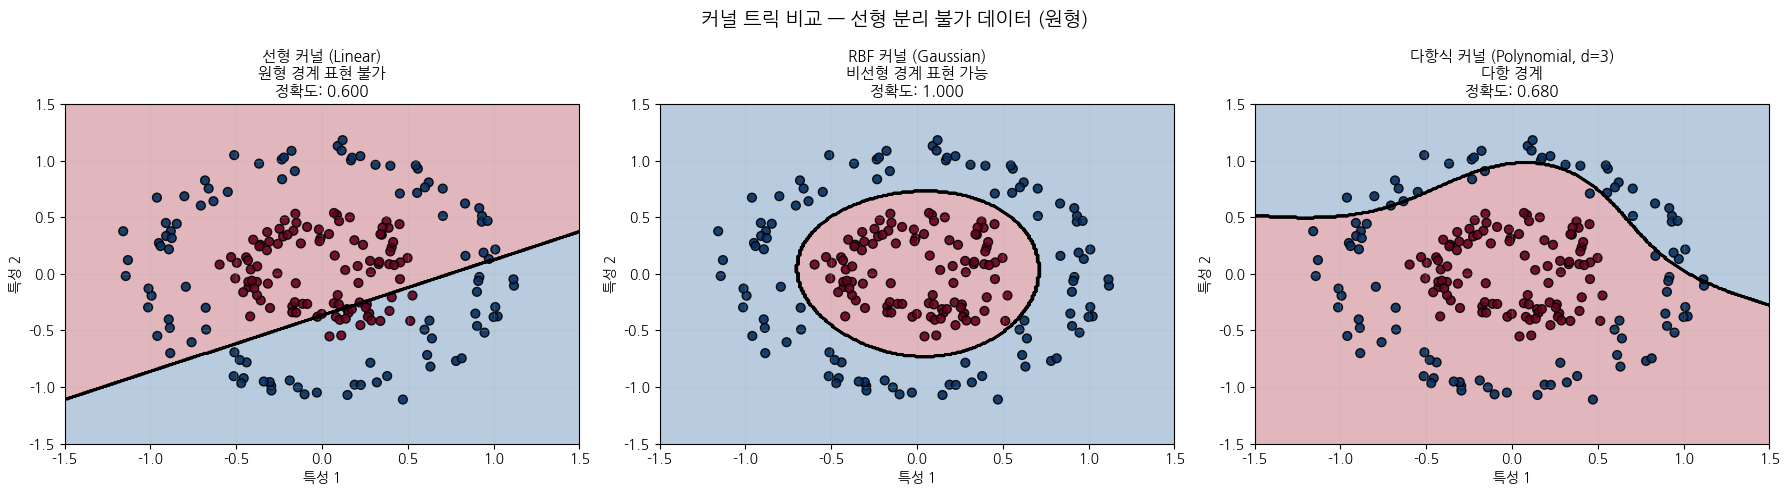

선형 커널: 원형 데이터를 직선으로 분리 불가 → 낮은 정확도
RBF 커널: 가우시안 변환으로 원형 경계 표현 → 높은 정확도
→ 비선형 데이터에는 RBF 커널이 가장 범용적으로 사용됨


In [15]:
# 선형으로 분리 불가능한 원형 데이터
X_circ, y_circ = make_circles(n_samples=200, noise=0.1, factor=0.4, random_state=42)
y_circ_pm = y_circ * 2 - 1   # {-1, +1}

kernels = [
    ('linear',  {'C': 1.0},              '선형 커널 (Linear)\n원형 경계 표현 불가'),
    ('rbf',     {'C': 1.0, 'gamma': 1.0}, 'RBF 커널 (Gaussian)\n비선형 경계 표현 가능'),
    ('poly',    {'C': 1.0, 'degree': 3},  '다항식 커널 (Polynomial, d=3)\n다항 경계'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (kernel, params, title) in zip(axes, kernels):
    model = SVC(kernel=kernel, **params)
    model.fit(X_circ, y_circ)

    xx_c, yy_c = np.meshgrid(
        np.linspace(-1.5, 1.5, 300), np.linspace(-1.5, 1.5, 300)
    )
    Z_c = model.predict(np.c_[xx_c.ravel(), yy_c.ravel()]).reshape(xx_c.shape)
    ax.contourf(xx_c, yy_c, Z_c, alpha=0.3, cmap='RdBu_r')
    ax.contour(xx_c, yy_c, Z_c, colors='black', linewidths=1.5)
    ax.scatter(X_circ[:, 0], X_circ[:, 1], c=y_circ,
               cmap='RdBu_r', edgecolors='k', s=40, alpha=0.9)
    acc = model.score(X_circ, y_circ)
    ax.set_title(f'{title}\n정확도: {acc:.3f}', fontsize=11)
    ax.set_xlabel('특성 1', fontsize=10)
    ax.set_ylabel('특성 2', fontsize=10)
    ax.grid(True, alpha=0.2)

plt.suptitle('커널 트릭 비교 — 선형 분리 불가 데이터 (원형)', fontsize=14)
plt.tight_layout()
plt.show()

print("선형 커널: 원형 데이터를 직선으로 분리 불가 → 낮은 정확도")
print("RBF 커널: 가우시안 변환으로 원형 경계 표현 → 높은 정확도")
print("→ 비선형 데이터에는 RBF 커널이 가장 범용적으로 사용됨")

---
## 요약

### 핵심 개념

| 주제 | 개념 | 주요 함수/수식 |
|---|---|---|
| **로지스틱 회귀 동기** | 선형 회귀는 확률 범위(0~1)를 벗어남 → Sigmoid로 변환 | — |
| **Sigmoid** | $\sigma(z) = \frac{1}{1+e^{-z}}$, $z=0$이 결정 경계 | `predict_proba()` |
| **Odds & Logit** | $\ln\frac{p}{1-p} = \mathbf{w}^T\mathbf{x}+b$: 선형 모델과 확률의 다리 | — |
| **Log Loss** | 볼록 함수 → 전역 최솟값 보장 (MSE+Sigmoid는 non-convex) | — |
| **계수 해석** | $e^{w_j}$ = Odds Ratio: $x_j$ 1단위 증가 시 양성 오즈의 배율 변화 | `coef_` |
| **다중 클래스** | Softmax: 모든 클래스 동시 학습, 예측 확률 합 = 1 보장 | `multi_class='multinomial'` |
| **SVM** | 마진 최대화: Support Vector만이 결정 경계를 결정 | `SVC` |
| **C 파라미터** | 크면 하드마진(마진 좁고 오분류 불허), 작으면 소프트마진(마진 넓고 오분류 허용) | `SVC(C=)` |
| **커널 트릭** | 고차원 변환 없이 내적으로 비선형 분리: RBF가 가장 범용 | `kernel='rbf'` |
